In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/processed_data_v1.csv')
print('Dataset loaded successfully.')
print('shape of the dataset:', df.shape)
df.head()

Dataset loaded successfully.
shape of the dataset: (17880, 12)


,telecommuting,has_company_logo,has_questions,fraudulent,job_description,jd_word_count,req_exp_enc,employment_type_Full-time,employment_type_Other,employment_type_Part-time,employment_type_Temporary,employment_type_Unknown
0,0,1,0,0,NaN,0,6.0,False,True,False,False,False
1,0,1,0,0,Customer Service - Cloud Video Production 90 S...,901,6.0,True,False,False,False,False
2,0,1,0,0,NaN,0,6.0,False,False,False,False,True
3,0,1,0,0,Account Executive - Washington DC Our passion ...,709,3.0,True,False,False,False,False
4,0,1,1,0,Bill Review Manager SpotSource Solutions LLC i...,470,3.0,True,False,False,False,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   telecommuting              17880 non-null  int64  
 1   has_company_logo           17880 non-null  int64  
 2   has_questions              17880 non-null  int64  
 3   fraudulent                 17880 non-null  int64  
 4   job_description            8845 non-null   object 
 5   jd_word_count              17880 non-null  int64  
 6   req_exp_enc                17880 non-null  float64
 7   employment_type_Full-time  17880 non-null  bool   
 8   employment_type_Other      17880 non-null  bool   
 9   employment_type_Part-time  17880 non-null  bool   
 10  employment_type_Temporary  17880 non-null  bool   
 11  employment_type_Unknown    17880 non-null  bool   
dtypes: bool(5), float64(1), int64(5), object(1)
memory usage: 1.0+ MB


In [4]:
# Handling missing values in 'job_description' column
df['job_description'] = df['job_description'].fillna("")
print('Missing values in job_description filled with empty strings.')

Missing values in job_description filled with empty strings.


In [5]:
# just checking it
df.job_description.isna().sum()

0

TF-IDF now

Separate Features & Target

In [6]:
X_text = df['job_description']
y = df['fraudulent']
print('Features are saperated.')

Features are saperated.


Create the TF-IDF Vectorizer

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

v = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)
print('TF-IDF vectorizer v created.')

TF-IDF vectorizer v created.


Fit & Transform the Text

In [8]:
X_tfidf = v.fit_transform(X_text)
print('Text is Fit & Transformed.')

Text is Fit & Transformed.


In [9]:
print(X_tfidf.shape)

(17880, 101108)


Prepare Structured (Non-Text) Features

In [10]:
structured_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'jd_word_count',
    'req_exp_enc',
    'employment_type_Full-time',
    'employment_type_Other',
    'employment_type_Part-time',
    'employment_type_Temporary',
    'employment_type_Unknown'
]
X_structured = df[structured_cols].astype(float)

X_structured.dtypes

telecommuting                float64
has_company_logo             float64
has_questions                float64
jd_word_count                float64
req_exp_enc                  float64
employment_type_Full-time    float64
employment_type_Other        float64
employment_type_Part-time    float64
employment_type_Temporary    float64
employment_type_Unknown      float64
dtype: object

Convert Structured Features to Sparse Matrix

In [11]:
from scipy.sparse import csr_matrix

X_structured_sparsed = csr_matrix(X_structured.values)

print('Converted Structured Features to Sparse Matrix')

Converted Structured Features to Sparse Matrix


Combine TF-IDF + Structured Features

In [12]:
from scipy.sparse import hstack

X = hstack([X_tfidf, X_structured_sparsed])

print('Now TF-IDF + Structured Features are combined.')

Now TF-IDF + Structured Features are combined.


In [13]:
# Sanity check
X.shape

(17880, 101118)

Baseline Model: Logistic Regression

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

model_logistic = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model_logistic.fit(X_train, y_train)

y_pred = model_logistic.predict(X_test)
y_prob = model_logistic.predict_proba(X_test)[:, 1]


In [20]:
from sklearn.metrics import classification_report
print('Logistic Regression Classification report: ')
print(classification_report(y_test, y_pred, digits=4))


Logistic Regression Classification report: 
              precision    recall  f1-score   support

           0     0.9784    0.8260    0.8958      3403
           1     0.1579    0.6416    0.2534       173

    accuracy                         0.8171      3576
   macro avg     0.5682    0.7338    0.5746      3576
weighted avg     0.9387    0.8171    0.8647      3576



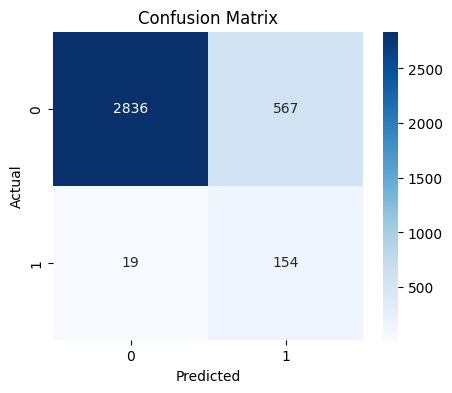

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [21]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score for Logistic Regression:", roc_auc)


ROC-AUC Score for Logistic Regression: 0.9084554770612125


Now comparing model with other algorithms
1. Linear SVM
2. XGBoost
3. LightBGM

1. Linear SVM

In [18]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(class_weight='balanced', max_iter=5000)

model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)

y_score = model_svm.decision_function(X_test)

print('Linear SVM Classification report: ')
report = classification_report(y_test, y_pred, digits=4)
print(report)

roc_auc = roc_auc_score(y_test, y_score)
print('ROC-AUC score: ', roc_auc)

Linear SVM Classification report: 
              precision    recall  f1-score   support

           0     0.9784    0.8260    0.8958      3403
           1     0.1579    0.6416    0.2534       173

    accuracy                         0.8171      3576
   macro avg     0.5682    0.7338    0.5746      3576
weighted avg     0.9387    0.8171    0.8647      3576

ROC-AUC score:  0.8199769329680203


C:\Users\being\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Confusion Matrix for Linear SVM


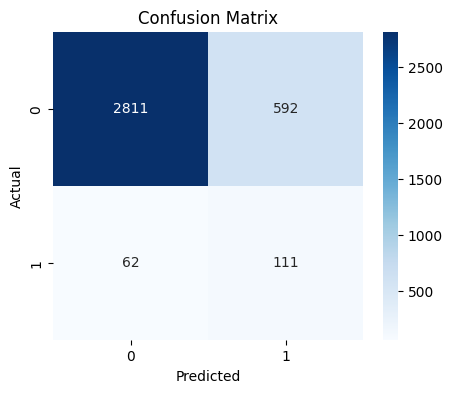

In [19]:
print('Confusion Matrix for Linear SVM')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Note:

Remaining two models in next notebook (XGBoost, LightBGM) 
"fraud_job_detection_2.ipynb"